# Avaliação dos Modelos de Machine Learning

Este notebook contém a avaliação dos modelos otimizados para previsão de preços de computadores.
São comparados modelos lineares (Lasso) e modelos baseados em árvores (XGBoost, LightGBM e CatBoost),
com análise de métricas, importância das features (SHAP), coeficientes, dispersão de predições e diagnóstico de resíduos.

## 1. Importação de Bibliotecas

Carregamento de todas as bibliotecas necessárias para análise, modelagem e visualização.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import shap

from sklearn.linear_model import Lasso
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from utils import plotar_qq_plot_residuos
from utils import avaliar_modelo, plotar_importancia_shap
from utils import plotar_top_coeficientes, plotar_real_vs_predito, plotar_distribuicao_residuos
from utils import plotar_erros_por_faixa

## 2. Carregamento e Preparação dos Dados

Leitura dos datasets previamente tratados (`linear.csv` para modelos lineares e `tree.csv` para modelos baseados em árvore).
A variável-alvo é `price_log` (preço com transformação logarítmica). Define-se também o número de folds para validação cruzada.

In [2]:
df_linear = pd.read_csv(os.path.join(os.getcwd(), 'csv_gerados', 'linear.csv'))

df_tree = pd.read_csv(os.path.join(os.getcwd(), 'csv_gerados', 'tree.csv'))

X_lin = df_linear.drop(columns=['price_log'])
y_lin = df_linear['price_log']

X_tree = df_tree.drop(columns=['price_log'])
y_tree = df_tree['price_log']

k_fold = 5

## 3. Configuração e Avaliação dos Modelos

Definição dos hiperparâmetros otimizados para cada modelo:

- **Lasso** (modelo linear) — avaliado sobre os dados do dataset `linear`
- **XGBoost, LightGBM e CatBoost** (modelos baseados em árvore) — avaliados sobre os dados do dataset `tree`

A avaliação utiliza **validação cruzada K-Fold (k=5)** com transformação inversa (`expm1`) para reportar as métricas em dólares.

In [3]:
modelo_linear = {"Lasso Otimizado": Lasso(alpha=0.00001, max_iter=10000, random_state=42)}


# ====================================================================
# MODELOS OTIMIZADOS — Hiperparâmetros via Optuna 
# ====================================================================

k_fold = 5
X_tree = df_tree.drop(columns=['price_log'])
y_tree = df_tree['price_log']

modelos_otimizados = {

    "XGBoost Otimizado": XGBRegressor(
        n_estimators=953,
        learning_rate=0.0313,
        max_depth=4,
        subsample=0.592,
        colsample_bytree=0.812,
        reg_alpha=1.693,
        reg_lambda=4.643,
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM Otimizado": LGBMRegressor(
        n_estimators=959,
        learning_rate=0.0437,
        max_depth=4,
        num_leaves=50,
        subsample=0.659,
        subsample_freq=1,
        colsample_bytree=0.596,
        random_state=42,
        verbose=-1,
        n_jobs=1
    ),

    "CatBoost Otimizado": CatBoostRegressor(
        iterations=849,
        learning_rate=0.0593,
        depth=5,
        l2_leaf_reg=9.819,
        subsample=0.720,
        bootstrap_type='Bernoulli',
        random_seed=42,
        verbose=False,
        thread_count=-1
    )
}
print(">>> AVALIANDO TODOS OS MODELOS OTIMIZADOS <<<\n")

avaliar_modelo(
    modelo=modelo_linear["Lasso Otimizado"],
    X=X_lin,
    y=y_lin,
    nome_modelo="Lasso Otimizado",
    cv=k_fold,
    transformacao="log1p"
)
for nome, modelo in modelos_otimizados.items():
    avaliar_modelo(
        modelo=modelo, 
        X=X_tree, 
        y=y_tree, 
        nome_modelo=nome, 
        cv=k_fold, 
        transformacao="log1p"
    )

>>> AVALIANDO TODOS OS MODELOS OTIMIZADOS <<<


 LASSO OTIMIZADO (K-Fold CV = 5)
--------------------------------------------------------------------------------------------
  Métrica  | Treino      | Validação   | Gap (V-T)  | IC 95% (Validação)      | Margem (±)
  -------- | ----------- | ----------- | ---------- | ----------------------- | ----------
  MAE      | $  207.48 | $  207.51 | +$   0.03  | [$  205.63, $  209.39] | ±$   1.88
  RMSE     | $  263.84 | $  263.87 | +$   0.03  | [$  261.14, $  266.61] | ±$   2.74
  R²       |    0.7812 |    0.7811 |   -0.0001  | [   0.7760,    0.7862] |  ± 0.0051


 XGBOOST OTIMIZADO (K-Fold CV = 5)
--------------------------------------------------------------------------------------------
  Métrica  | Treino      | Validação   | Gap (V-T)  | IC 95% (Validação)      | Margem (±)
  -------- | ----------- | ----------- | ---------- | ----------------------- | ----------
  MAE      | $  131.01 | $  134.13 | +$   3.12  | [$  132.65, $  135.61] | ±$

## 4. Análise dos Coeficientes — Regressão Lasso

Inspeção dos coeficientes do modelo Lasso para entender a direção e magnitude do impacto de cada feature.

- **Gráfico geral**: todos os coeficientes ordenados (positivos em azul, negativos em vermelho)
- **Top 20**: features com maior peso em valor absoluto, com valores anotados

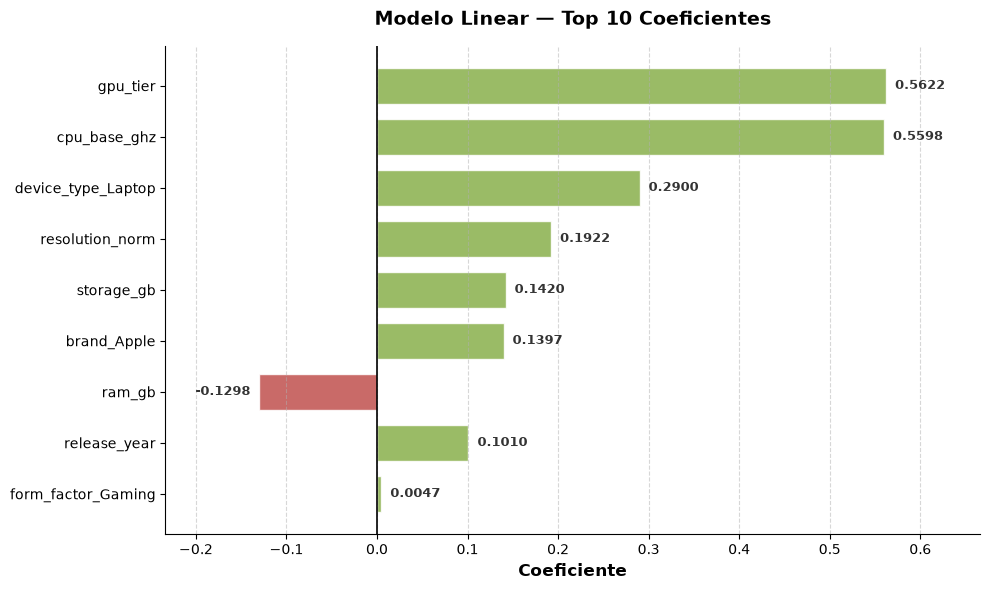


--- Tabela das Top 10 Features ---


,Feature,Coeficiente
0,gpu_tier,0.562160
1,cpu_base_ghz,0.559830
2,device_type_Laptop,0.289974
3,resolution_norm,0.192206
4,storage_gb,0.141984
5,brand_Apple,0.139725
6,ram_gb,-0.129793
7,release_year,0.101018
8,form_factor_Gaming,0.004741


In [4]:
modelo_lasso = modelo_linear["Lasso Otimizado"]

modelo_lasso.fit(X_lin, y_lin)

df_coefs = pd.DataFrame({
    'Feature': X_lin.columns,
    'Coeficiente': modelo_lasso.coef_
})

plotar_top_coeficientes(df_coefs, top_n=10, titulo='Modelo Linear — Top 10 Coeficientes')

## 5. Importância das Features — Análise SHAP

Cálculo dos valores SHAP sobre uma amostra de 2.000 observações para quantificar a contribuição
de cada feature nas predições dos modelos baseados em árvore.

### 5.1 Importância SHAP — Cada Modelo Individualmente

Gráficos de importância SHAP para XGBoost, CatBoost e LightGBM separadamente (Top 15 features).

findfont: Failed to find font weight 500, now using 400.


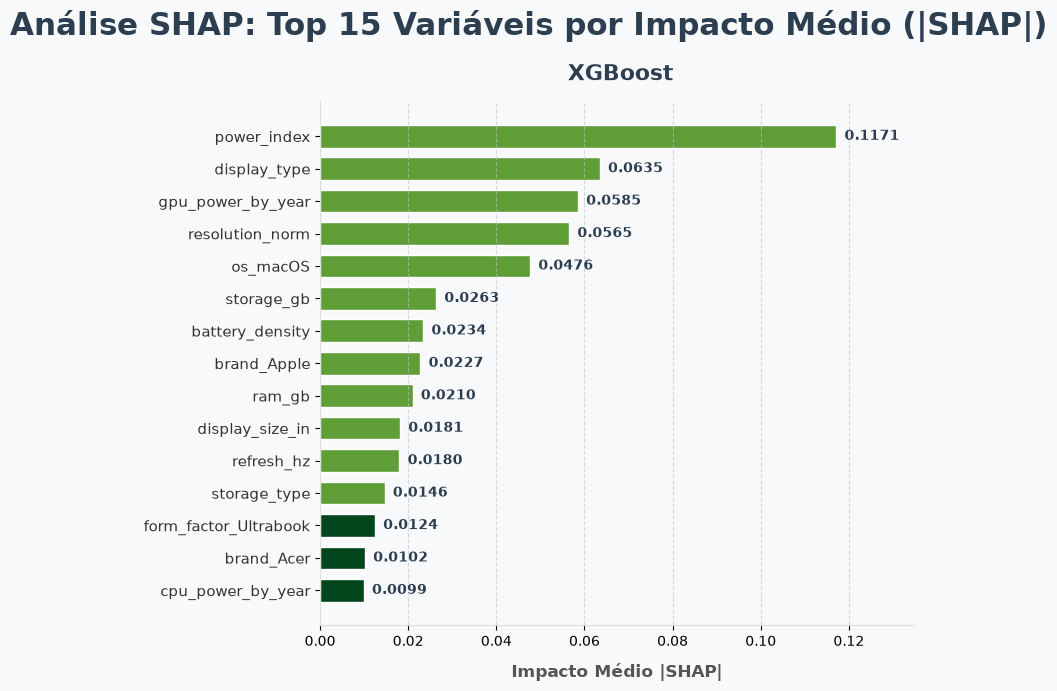

In [5]:
X_amostra = X_tree.sample(n=min(2000, len(X_tree)), random_state=42)

# 1. Calculando para o XGBoost
explainer_xgb = shap.TreeExplainer(modelos_otimizados["XGBoost Otimizado"])
shap_values_xgb = explainer_xgb.shap_values(X_amostra)

# 2. Calculando para o LightGBM
explainer_lgbm = shap.TreeExplainer(modelos_otimizados["LightGBM Otimizado"])
shap_values_lgbm = explainer_lgbm.shap_values(X_amostra)

# 3. Calculando para o CatBoost
explainer_cat = shap.TreeExplainer(modelos_otimizados["CatBoost Otimizado"])
shap_values_cat = explainer_cat.shap_values(X_amostra)

# 4. Agrupando no dicionário
meus_shaps = {
    "XGBoost": shap_values_xgb,
}

plotar_importancia_shap(meus_shaps, features=X_tree.columns, top_n=15)

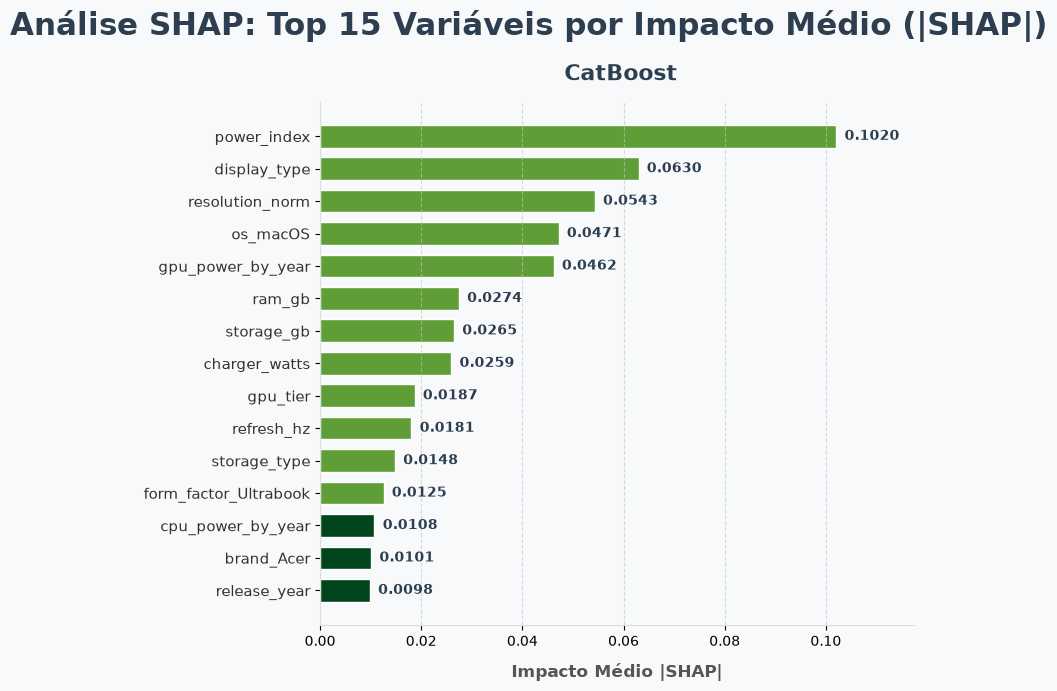

In [6]:
meus_shaps = {
    "CatBoost": shap_values_cat,
}

plotar_importancia_shap(meus_shaps, features=X_tree.columns, top_n=15)

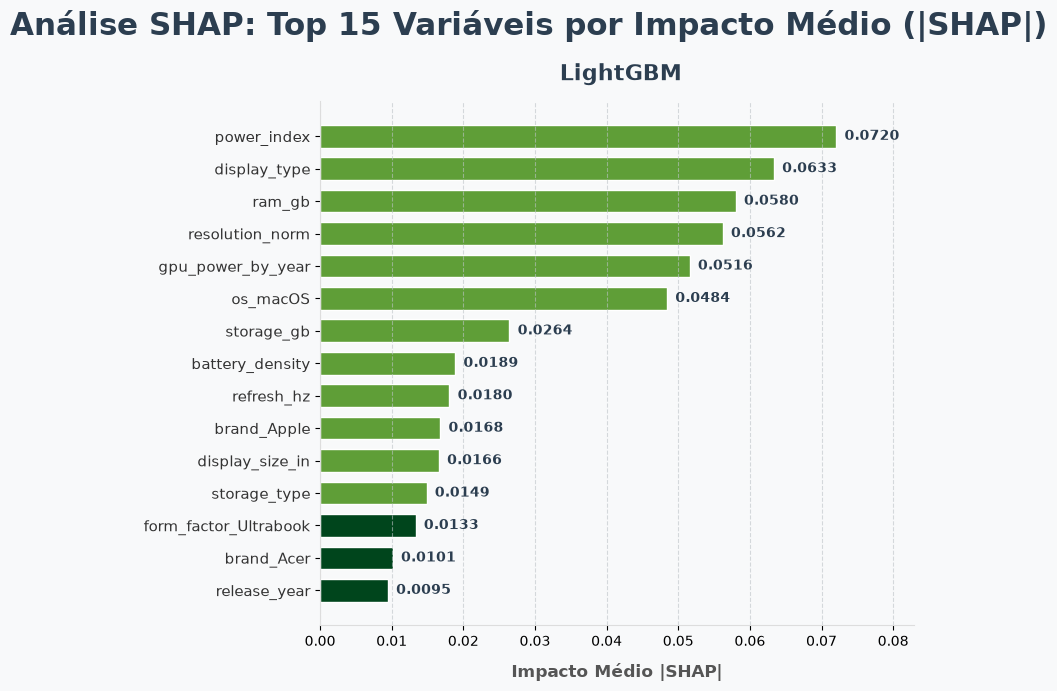

In [7]:
meus_shaps = {
    "LightGBM": shap_values_lgbm,
}

plotar_importancia_shap(meus_shaps, features=X_tree.columns, top_n=15)

> ### Features mais Relevantes
> 
> **A feature Power_Index , Display_Type e Ram** aparacem como mais relevantes nos 3 modelos de Boosting
>
> Além disso, **os_MacOS** ( indicando que computadores da apple realmente apresentam maiores preços) está no top10 também.
>
> **Resolução** também é um grande fator dos modelos

## 6. Análise da Qualidade das Predições

Avaliação visual da qualidade das predições através de três análises complementares:

1. **Gráfico de dispersão** (Real vs Predito) — quão próximas as predições estão dos valores reais
2. **Distribuição dos resíduos** — simetria e centralidade dos erros
3. **QQ Plot** — normalidade dos resíduos

### 6.1 Gráfico de Dispersão — Real vs Predito

Cada ponto representa uma observação. A linha tracejada indica a predição perfeita.
Quanto mais próximos os pontos da diagonal, melhor o modelo.

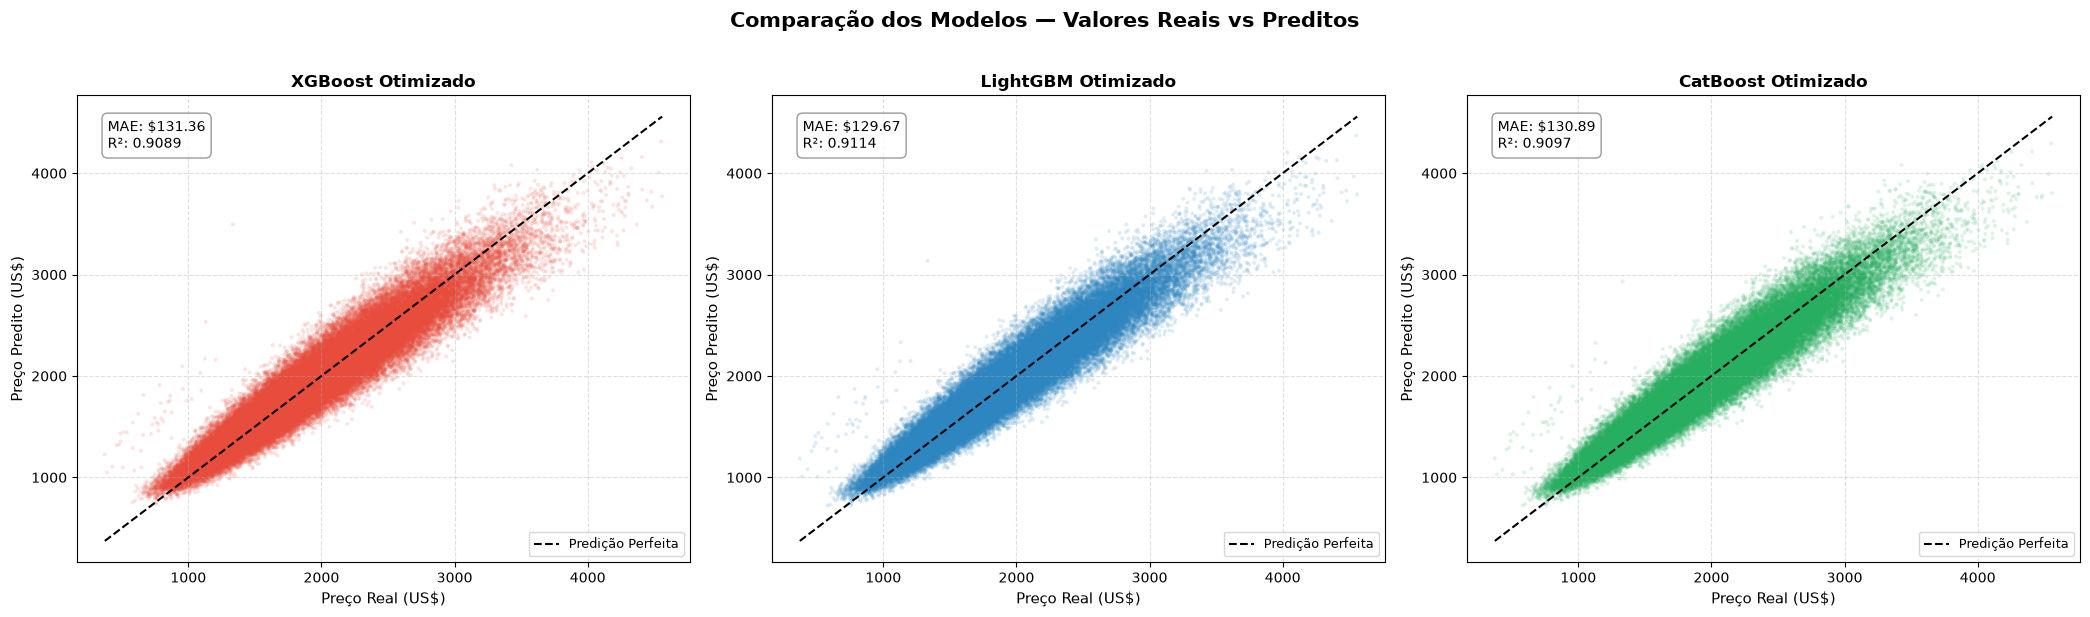

In [8]:
minhas_cores = {
    'XGBoost Otimizado': '#E74C3C',     
    'LightGBM Otimizado': '#2E86C1',    
    'CatBoost Otimizado': '#27AE60'     
}

# 2. Chame a função passando os dois dicionários
plotar_real_vs_predito(
    modelos_dict=modelos_otimizados, 
    X=X_tree, 
    y_true_log=y_tree,
    cores_dict=minhas_cores  # <-- Injeta as cores personalizadas aqui
)

> ### Consistência dos modelos
> 
> **Os 3 modelos apresentam alta consistência nas previsões** e a princípio apresentam os maiores indícios de erros para valores altos ( no 4 quartil)
>

### 6.2 Distribuição dos Resíduos

Histograma dos erros (Real − Predito) para cada modelo.
Uma distribuição centrada em zero e simétrica indica que o modelo não possui viés sistemático.

=== ESTATÍSTICAS DOS RESÍDUOS ===

[XGBoost Otimizado]
  Média         : $7.45
  Desvio Padrão : $170.07
  Assimetria    : 0.112
  Curtose       : 1.386

[LightGBM Otimizado]
  Média         : $7.51
  Desvio Padrão : $167.76
  Assimetria    : 0.128
  Curtose       : 1.171

[CatBoost Otimizado]
  Média         : $7.57
  Desvio Padrão : $169.38
  Assimetria    : 0.129
  Curtose       : 1.125




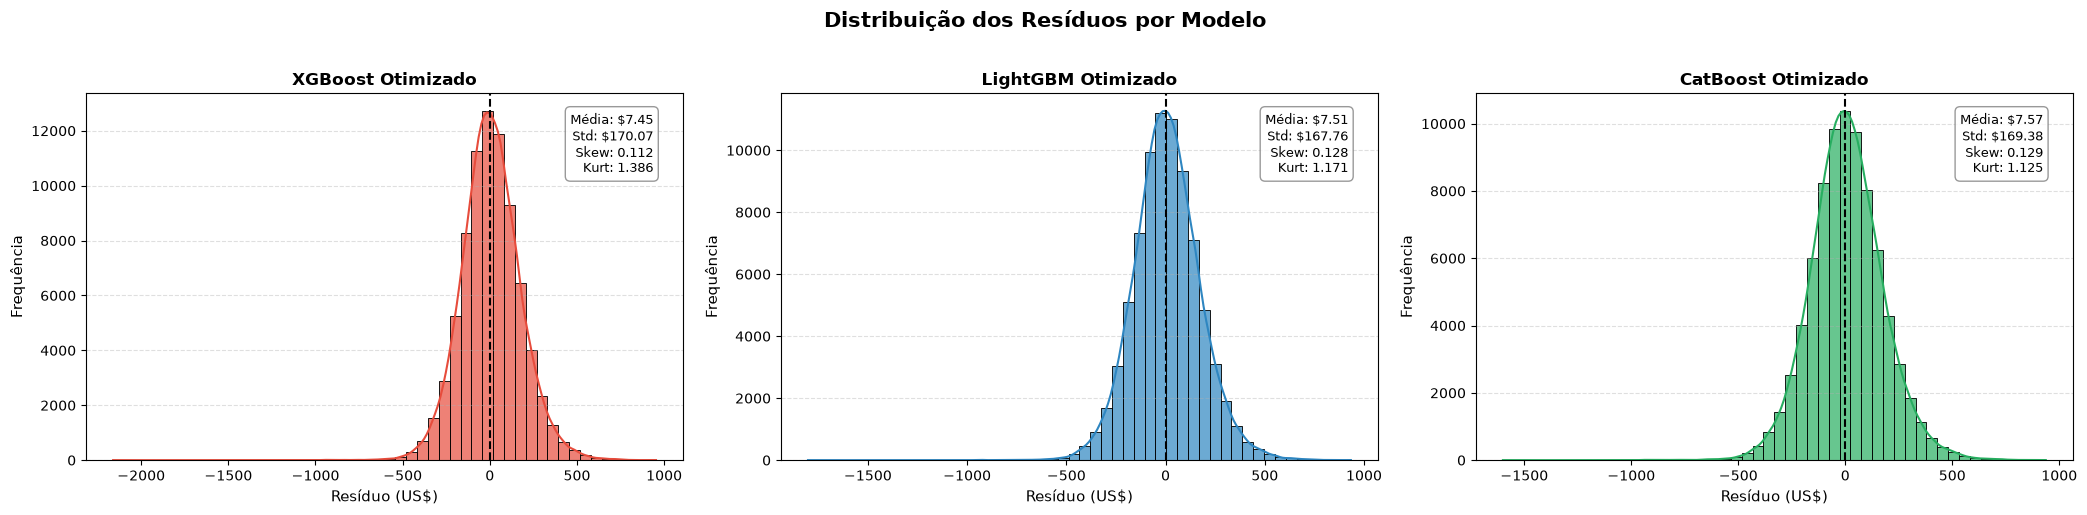

In [9]:
minhas_cores = {
    'XGBoost Otimizado': '#E74C3C',
    'LightGBM Otimizado': '#2E86C1',
    'CatBoost Otimizado': '#27AE60'
}

# Chamada da função
plotar_distribuicao_residuos(
    modelos_dict=modelos_otimizados, 
    X=X_tree, 
    y_true_log=y_tree, 
    cores_dict=minhas_cores
)

> ### Resíduos bem distribuidos 
> 
> Os 3 modelos apresentam **baixa assimetria( na faixa de 0.130)**, indicando desvio consistentes em qualquer faixa e leve cauda a direita
>
> O erro médio está na faixa dos **7.5$**

### 6.3 QQ Plot dos Resíduos

O QQ Plot compara os quantis dos resíduos com os quantis de uma distribuição normal teórica.
Pontos próximos da linha diagonal indicam resíduos com distribuição aproximadamente normal.

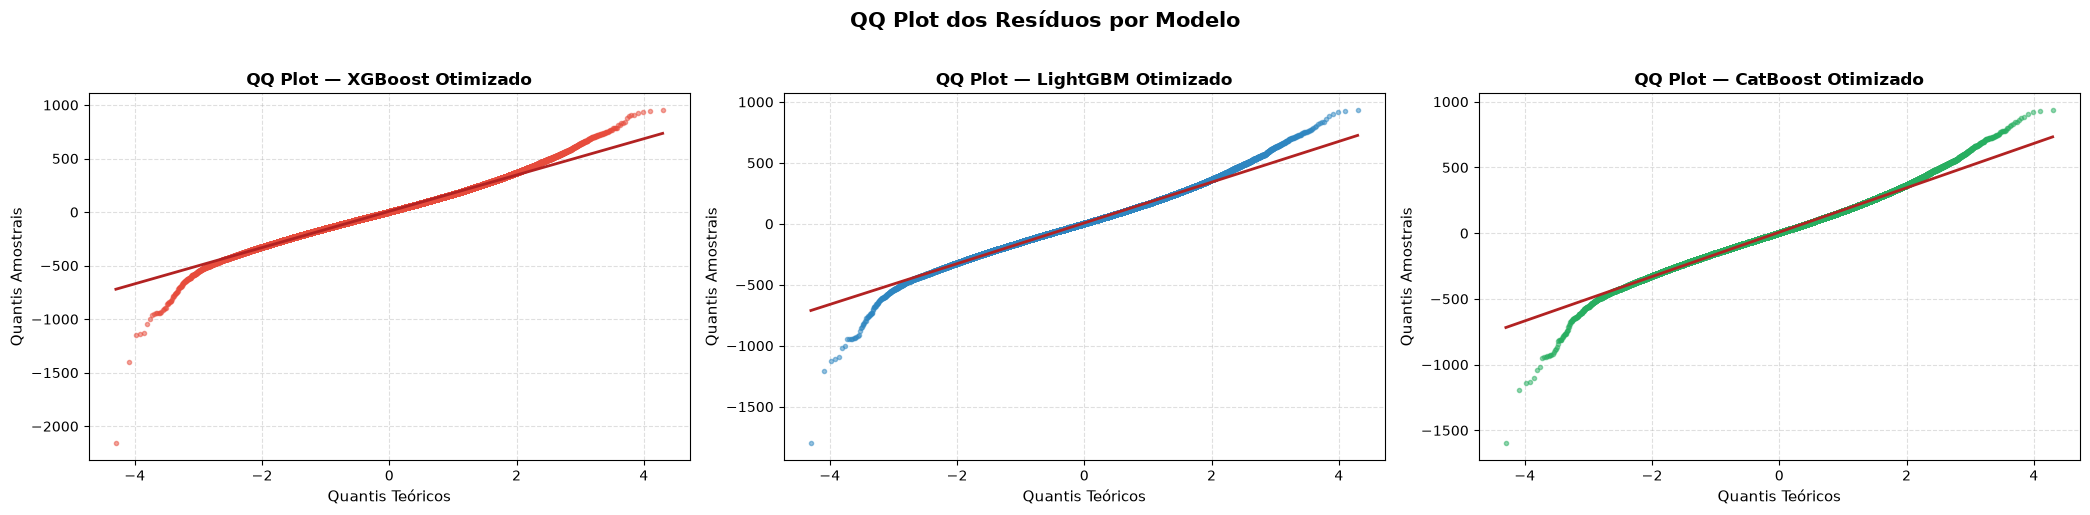

In [10]:
minhas_cores = {
    'XGBoost Otimizado': '#E74C3C',
    'LightGBM Otimizado': '#2E86C1',
    'CatBoost Otimizado': '#27AE60'
}


plotar_qq_plot_residuos(
    modelos_dict=modelos_otimizados, 
    X=X_tree, 
    y_true_log=y_tree, 
    cores_dict=minhas_cores
)

> ### Onde os modelos mais erram?
> 
> Os 3 modelos apresentam boa precisão na análise dos quantis -3 a +3
>
> Ao analisar computadores **muito baratos** e **muito caros** nosso modelo apresenta distorções maiores
>
> Entretanto, isso não parece ser um problema muito significativo já que **promoções/lançamentos** não podem ser previstos com os dados informados
>
> Na verdade, os 3 modelos de boosting otimizados apresentam previsões **excelentes na faixa de preço normal**

## 7. Análise de Erros por Faixa de Preço

Segmentação dos preços reais em quartis para avaliar onde cada modelo acerta mais e onde erra mais.

=== Tabela de Erros por Faixa de Preço ===


Modelo,CatBoost Otimizado,LightGBM Otimizado,XGBoost Otimizado
Faixa de Preço,,,
Q1 (Mais Baratos),8.10%,8.01%,8.15%
Q2 (Intermediários),6.84%,6.80%,6.87%
Q3 (Avançados),6.50%,6.44%,6.51%
Q4 (Premium),6.48%,6.42%,6.51%


Modelo,CatBoost Otimizado,LightGBM Otimizado,XGBoost Otimizado
Faixa de Preço,,,
Q1 (Mais Baratos),$130.01,$128.81,$131.11
Q2 (Intermediários),$145.15,$144.36,$145.80
Q3 (Avançados),$167.81,$166.24,$168.04
Q4 (Premium),$221.05,$218.51,$221.90


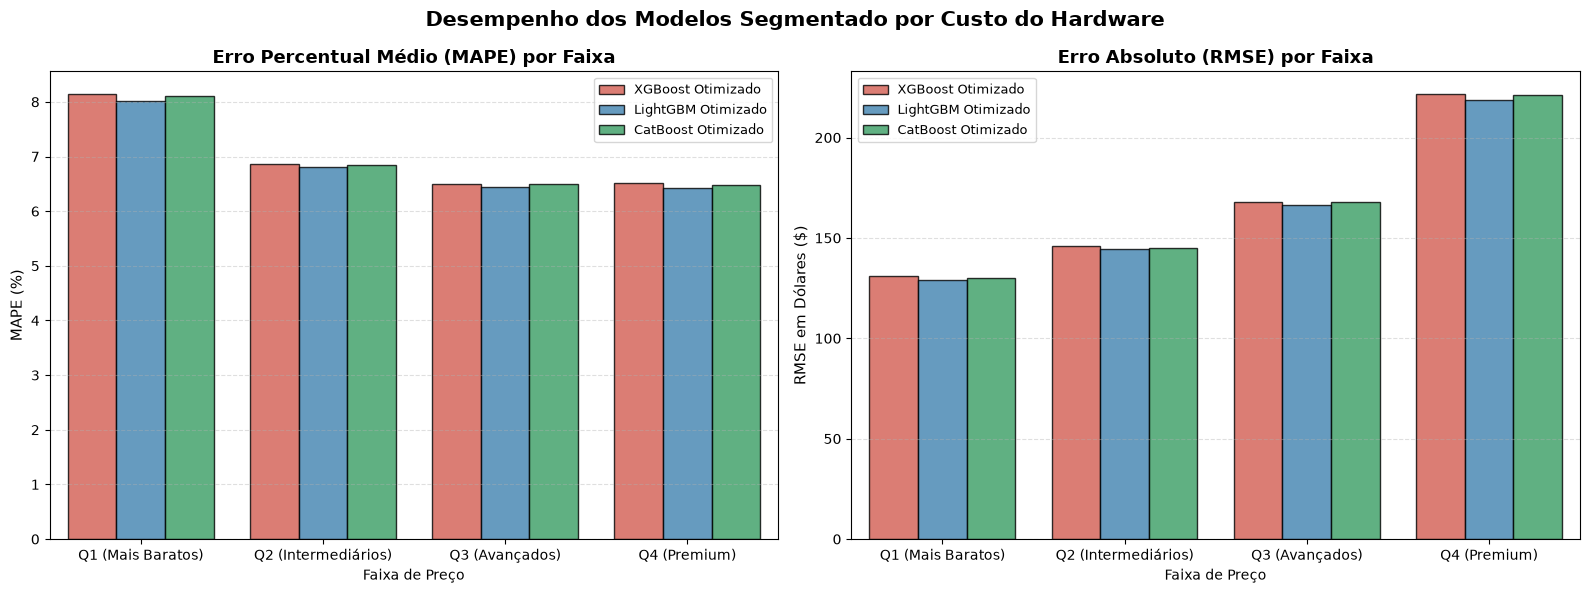

In [11]:
plotar_erros_por_faixa(
    modelos_dict=modelos_otimizados, 
    X=X_tree, 
    y_true_log=y_tree, 
    cores_dict=minhas_cores
)

> ### RMSE aumenta nos extremos
> 
> Os 3 modelos aumentam suas métricas de erro ao prever computadores nos extremos de preço, tanto muito caros (>3200$) como muito baratos (<800$).



## 8. Veredito Final — Melhor Modelo

> **CatBoost Otimizado** foi o modelo com melhor desempenho geral na validação cruzada (K-Fold = 5).

### Métricas de Validação

| Métrica | CatBoost | XGBoost | LightGBM | Lasso |
|---------|----------|---------|----------|-------|
| **MAE** | **$ 133.51** | $ 134.13 | $ 134.12 | $ 207.51 |
| **RMSE** | **$ 173.16** | $ 173.92 | $ 174.00 | $ 263.87 |
| **R²** | **0.9058** | 0.9049 | 0.9048 | 0.7811 |

---

### Insights

> O CatBoost é **excelente para prever computadores na faixa intermediária (Q2 e Q3)**, onde seus erros são consistentemente menores que os dos concorrentes.

> Tem **mais dificuldade nos extremos** — computadores do **1º quartil (mais baratos)** e do **4º quartil (premium)** — onde os erros sobem para a faixa de **~$60 ou mais**, um padrão compartilhado com XGBoost e LightGBM.

> O **gap entre treino e validação** do CatBoost (MAE: +$3.13 / RMSE: +$4.31) é **pequeno e controlado**, indicando baixo overfitting — comparável ao XGBoost e inferior ao LightGBM, que apresentou o maior gap (MAE: +$5.21).

> A **análise SHAP** mostra que as features mais impactantes são consistentes entre os três modelos baseados em árvore: `gpu_tier`, `cpu_base_ghz` e `resolution_norm` dominam as predições, seguidas por `ram_gb` e `storage_gb`.

> O modelo **Lasso** (linear), mesmo otimizado, ficou **muito atrás** dos modelos baseados em árvore (MAE ~$74 maior), confirmando que a relação entre as features e o preço é **predominantemente não-linear**.

> Os **resíduos dos três modelos de árvore** são aproximadamente simétricos (assimetria ~0.11–0.13) e centrados próximo de zero (média ~$7.5), sem viés relevante aparente

---

### Conclusão

O **CatBoost Otimizado** é a escolha recomendada para produção por combinar:
- **Menor MAE e RMSE** em validação cruzada
- **Maior R²** (0.9058)
- **Overfitting controlado** (gap pequeno entre treino e validação)
- **Resíduos bem comportados** (simétricos e centrados em zero)